In [1]:
from pathlib import Path
import pickle
import faiss
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms


In [2]:
device= torch.device("cuda" if torch.cuda.is_available() else "CPU")

In [3]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.model.fc=nn.Identity()
    def forward(self,x):
        return self.model(x)

In [4]:
Model = FeatureExtractor().to(device)
Model.eval()

FeatureExtractor(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

In [5]:
PROJECT_PATH=Path (r"C:\Users\goura\OneDrive\Desktop\image_Similarity\visual-product-search")
INDEX_DIR=PROJECT_PATH/ "data"/ "faiss"
EMBD_DIR=PROJECT_PATH/ "data" / "embeddings"


In [6]:
index=faiss.read_index(str(INDEX_DIR / "product_index.faiss"))
with open( EMBD_DIR / "train_paths.pkl","rb") as f:
    img_paths = pickle.load(f)

In [7]:
transforms=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
query_pth=Path(r"C:\Users\goura\OneDrive\Desktop\image_Similarity\visual-product-search\data\raw\Stanford_Online_Products\kettle_final\110878471151_1.JPG")
query_img=Image.open(query_pth).convert("RGB")

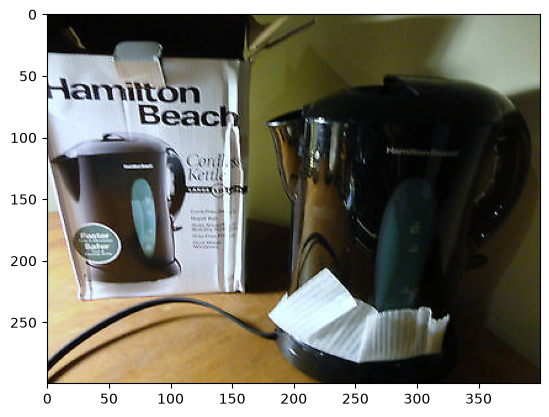

In [9]:
plt.imshow(query_img)
plt.show()

In [10]:
query_tensor=transforms(query_img).unsqueeze(0)
query_tensor=query_tensor.to(device)

In [11]:
query_tensor.shape

torch.Size([1, 3, 128, 128])

In [12]:
q_embd=[]
with torch.no_grad():
    q_emdb=Model(query_tensor)
    q_embd.append(q_embd)

In [13]:
q_emd=q_emdb.cpu().numpy()

In [14]:
q_embd

[[...]]

In [15]:
def retrivel_images(q_image_path,Model,index,transforms,o_images_path,device,k=5):
    image=Image.open(q_image_path).convert("RGB")
    tensor=transforms(image)
    tensor=tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        embd=Model(tensor)
    embd=embd.cpu().numpy()
    faiss.normalize_L2(embd)
    distance,indics=index.search(embd,k)
    return image,distance,indics

In [18]:
q_img,distance,indics=retrivel_images(
  q_image_path=query_pth,
    Model=Model,
    index=index,
    transforms=transforms,
    o_images_path=img_paths,
    device=device,
    k=5
)

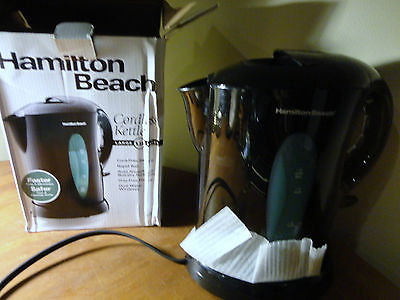

In [19]:
q_img